In [1]:
import numpy as np #Нужные библиотеки
import matplotlib.pyplot as plt

In [2]:
def least_squares(x_arr, y_arr): #Подпрограмма МНК для прямой
    size= x_arr.shape[0]
    b=(np.sum(y_arr)*np.sum(x_arr**2)-np.sum(x_arr)*np.sum(x_arr*y_arr))/(size*np.sum(x_arr**2)-np.sum(x_arr)**2)
    a=(np.sum(y_arr)-size*b)/np.sum(x_arr)
    return a, b

In [21]:
N=range(100000-1)
N=np.array(N)
N=N+1
with open('l1t1s1.txt', 'r') as file: #Парсинг
    lines=file.readlines()
l1t1s1=np.array([int(line.strip()) for line in lines])
with open('l1t1s2.txt', 'r') as file: #Парсинг
    lines=file.readlines()
l1t1s2=np.array([int(line.strip()) for line in lines])
with open('l1t1s3.txt', 'r') as file: #Парсинг
    lines=file.readlines()
l1t1s3=np.array([int(line.strip()) for line in lines])

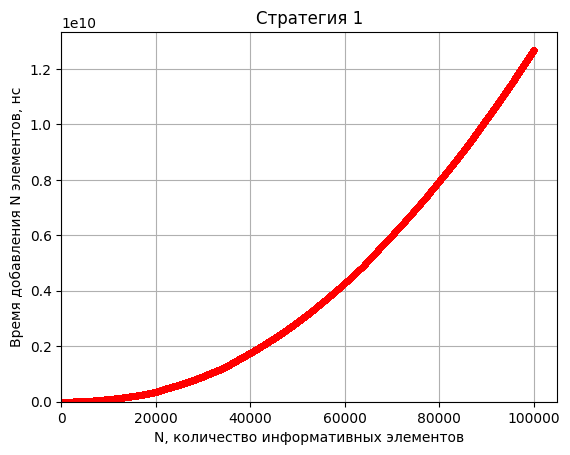

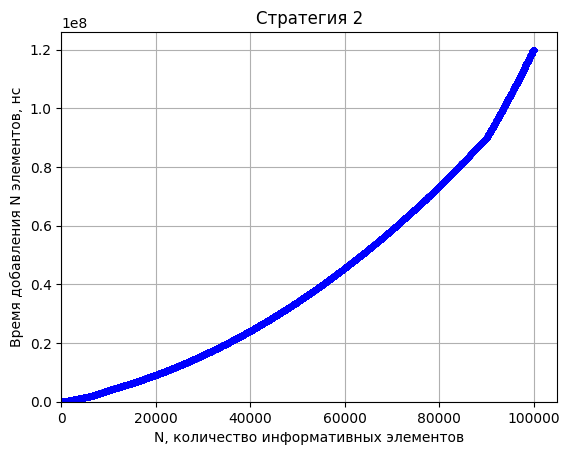

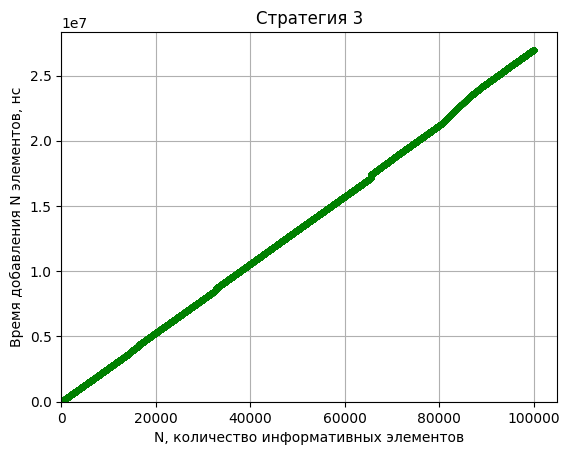

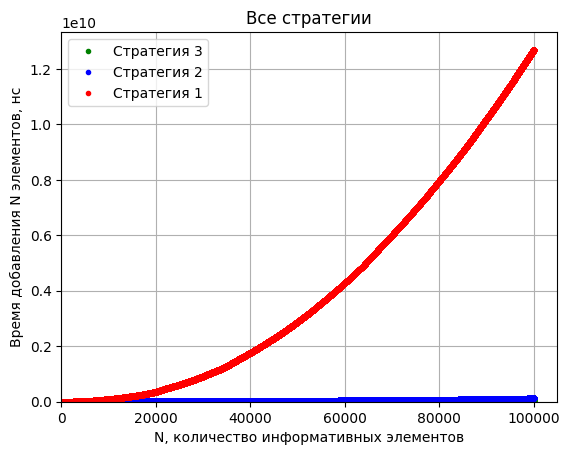

In [22]:
fig, L1T1S1 = plt.subplots()
fig, L1T1S2 = plt.subplots()
fig, L1T1S3 = plt.subplots()
fig, L1T1 = plt.subplots()

L1T1S1.plot(N, l1t1s1, '.', color='r', label="Стратегия 1")
L1T1S1.grid()

L1T1S2.plot(N, l1t1s2, '.', color='b', label="Стратегия 2")
L1T1S2.grid()

L1T1S3.plot(N, l1t1s3, '.', color='g', label="Стратегия 3")
L1T1S3.grid()

L1T1.plot(N, l1t1s3, '.', color='g', label="Стратегия 3")
L1T1.plot(N, l1t1s2, '.', color='b', label="Стратегия 2")
L1T1.plot(N, l1t1s1, '.', color='r', label="Стратегия 1")
L1T1.grid()

L1T1S1.set(xlabel='N, количество информативных элементов', ylabel='Время добавления N элементов, нс', title='Стратегия 1', ylim=(0), xlim=(0))
L1T1S2.set(xlabel='N, количество информативных элементов', ylabel='Время добавления N элементов, нс', title='Стратегия 2', ylim=(0), xlim=(0))
L1T1S3.set(xlabel='N, количество информативных элементов', ylabel='Время добавления N элементов, нс', title='Стратегия 3', ylim=(0), xlim=(0))
L1T1.set(xlabel='N, количество информативных элементов', ylabel='Время добавления N элементов, нс', title='Все стратегии', ylim=(0), xlim=(0))
L1T1.legend()

Ассимптотика добавления N элементов для первой и второй стратегии похожа на параболу, а у третьей на прямую.
Проверим это, построив графики в логарифмическом масштабе и посчитав угловые коэффициенты с помощью МНК.
Чтобы найти ассимптотику добавления одного элемента возьмём производную от ассимптотики добавления N элементов. Таким образом, если ассимптотика имеет полиномиальный характер, то степень понизится на 1.

2.021362690166718 1.3533357005597588 1.0082228066330277


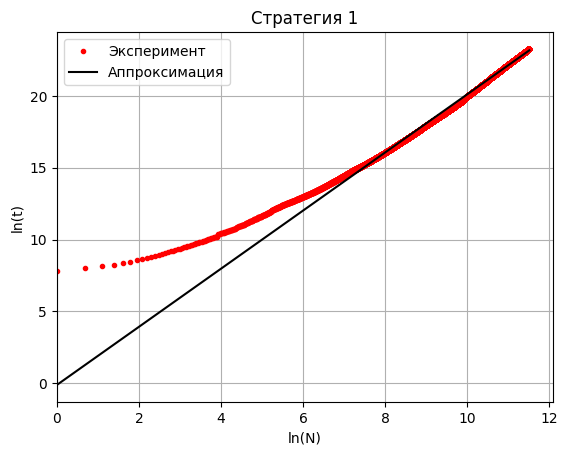

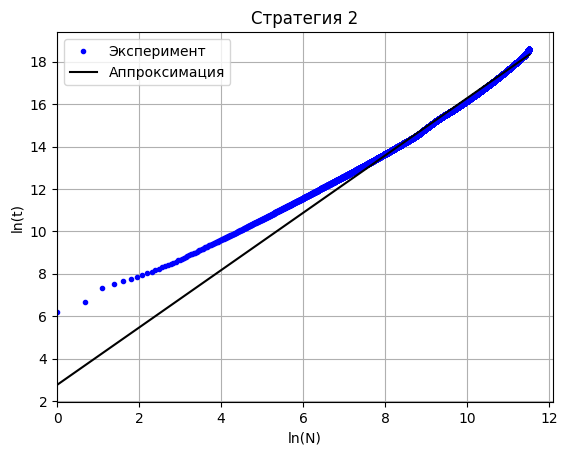

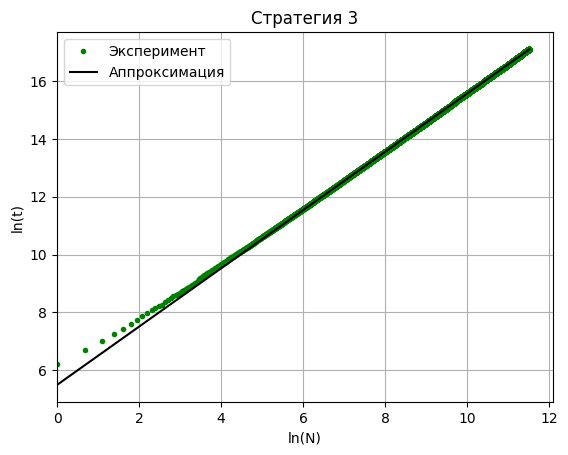

In [29]:
fig, L1T1S1log = plt.subplots()
fig, L1T1S2log = plt.subplots()
fig, L1T1S3log = plt.subplots()

a1, b1=least_squares(np.log(N),np.log(l1t1s1))
a2, b2=least_squares(np.log(N),np.log(l1t1s2))
a3, b3=least_squares(np.log(N),np.log(l1t1s3))

L1T1S1log.plot(np.log(N), np.log(l1t1s1), '.', color='r', label="Эксперимент")
L1T1S1log.plot(np.log(N), a1*np.log(N)+b1, color='black', label="Аппроксимация")
L1T1S1log.grid()
L1T1S1log.legend()

L1T1S2log.plot(np.log(N), np.log(l1t1s2), '.', color='b', label="Эксперимент")
L1T1S2log.plot(np.log(N), a2*np.log(N)+b2, color='black', label="Аппроксимация")
L1T1S2log.grid()
L1T1S2log.legend()

L1T1S3log.plot(np.log(N), np.log(l1t1s3), '.', color='g', label="Эксперимент")
L1T1S3log.plot(np.log(N), a3*np.log(N)+b3, color='black', label="Аппроксимация")
L1T1S3log.grid()
L1T1S3log.legend()

L1T1S1log.set(xlabel='ln(N)', ylabel='ln(t)', title='Стратегия 1', xlim=(0))
L1T1S2log.set(xlabel='ln(N)', ylabel='ln(t)', title='Стратегия 2', xlim=(0))
L1T1S3log.set(xlabel='ln(N)', ylabel='ln(t)', title='Стратегия 3', xlim=(0))

print(a1, a2, a3)

МНК для всех точек дало хорошее описание только для третьей стратегии, для неё угловой коэффициент получился равным 1.008, значит с хорошей точностью ассимптотика добавления $N$ точек это $O(N)$, то есть добавления одной точки $O(1)$, что соответствует теории.
По графикам можно сказать, что ассимптотика стратегии 1 это $O(N^2)$ (угловой коэффициент 2.02), а стратегия 2 имеет наиболее выраженную амортизированную ассимптотику между $O(N)$ и $O(N^2)$ (угловой коэффициент 1.35).
Итак, ассимптотика добавления одного элемента для трёх стратегий соответственно: $O(N)$, между $O(N)$ и $O(1)$, $O(1)$.
То есть самой выгодной стратегией является третья.